In [2]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [3]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
# ─── Cell 2: Configuration ───────────────────────────────────────────────────
# Paths to image folders
CANCER_DIR = "../data/raw/cancer"
NORMAL_DIR = "../data/raw/normal"

# All images will be resized to this dimension
IMG_SIZE = 128

In [9]:
# ─── Cell 3: Load and Preprocess Images ──────────────────────────────────────

images = []   # will hold processed image arrays
labels = []   # will hold 0 (normal) or 1 (cancer)

def load_images_from_folder(folder_path, label):
    """
    Reads every image in a folder, converts to grayscale,
    resizes to IMG_SIZE x IMG_SIZE, and appends to the global lists.
    Corrupted or unreadable files are silently skipped.
    """
    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)
        try:
            # Read image in colour first, then convert
            img = cv2.imread(filepath)
            if img is None:
                # File exists but OpenCV couldn't decode it
                print(f"  Skipping (unreadable): {filename}")
                continue

            img_gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   # → grayscale
            img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))  # → 128×128

            images.append(img_resized)
            labels.append(label)

        except Exception as e:
            # Skip anything that raises an unexpected error
            print(f"  Skipping (error) {filename}: {e}")

# Load both classes
print("Loading cancer images …")
load_images_from_folder(CANCER_DIR, label=1)

print("Loading normal images …")
load_images_from_folder(NORMAL_DIR, label=0)

print(f"\nTotal images loaded: {len(images)}")

Loading cancer images …
Loading normal images …

Total images loaded: 977


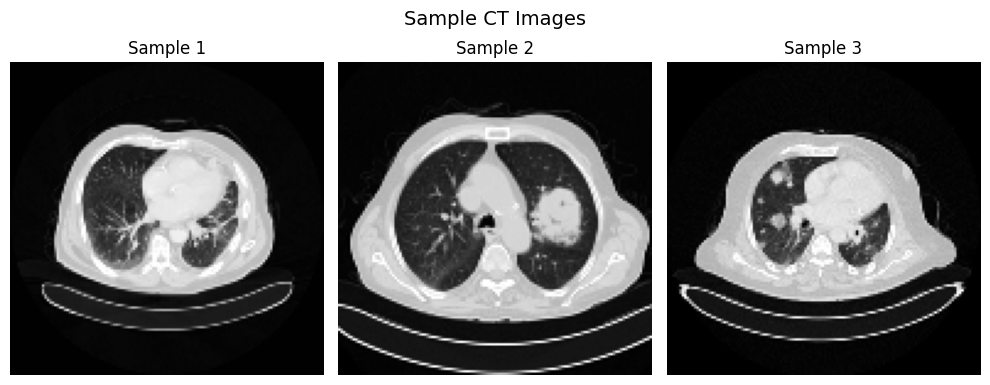

In [10]:
# ─── Cell 4: Show Sample Images (optional) ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
titles = ["Sample 1", "Sample 2", "Sample 3"]

for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(titles[i])
    ax.axis("off")

plt.suptitle("Sample CT Images", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# ─── Cell 5: Convert to NumPy, Normalize, and Reshape ────────────────────────

# Convert Python lists → NumPy arrays
X = np.array(images)   # shape: (num_images, 128, 128)
y = np.array(labels)   # shape: (num_images,)

# Normalize pixel values from [0, 255] → [0.0, 1.0]
# This helps the model learn faster and more stably
X = X / 255.0

# Reshape for CNN: add a channel dimension → (num_images, 128, 128, 1)
# CNNs expect (batch, height, width, channels); grayscale = 1 channel
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print(f"X shape after reshape : {X.shape}")
print(f"y shape               : {y.shape}")

X shape after reshape : (977, 128, 128, 1)
y shape               : (977,)


In [12]:
# ─── Cell 6: Train / Test Split ──────────────────────────────────────────────

# 80% training data, 20% testing data
# random_state=42 ensures you get the same split every time you run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ─── Final Summary ───────────────────────────────────────────────────────────
print("=" * 40)
print("  Dataset Split Summary")
print("=" * 40)
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")
print("=" * 40)
print("  Phase 2 complete — ready for modelling!")

  Dataset Split Summary
  X_train : (781, 128, 128, 1)
  X_test  : (196, 128, 128, 1)
  y_train : (781,)
  y_test  : (196,)
  Phase 2 complete — ready for modelling!


In [13]:
# ML models (KNN, SVM) require 1D feature vectors, not 2D images
# So we flatten each 128x128 image into a single vector (128*128 = 16384)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("Flattened train shape:", X_train_flat.shape)
print("Flattened test shape :", X_test_flat.shape)

Flattened train shape: (781, 16384)
Flattened test shape : (196, 16384)


In [14]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model (k=3 means 3 nearest neighbors)
knn_model = KNeighborsClassifier(n_neighbors=3)

# Train model using training data
knn_model.fit(X_train_flat, y_train)

print("KNN model trained successfully ✅")

KNN model trained successfully ✅


In [15]:
from sklearn.metrics import accuracy_score

# Predict on test data
y_pred_knn = knn_model.predict(X_test_flat)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9897959183673469


In [16]:
from sklearn.svm import SVC

# Create SVM model (linear kernel)
svm_model = SVC(kernel='linear')

# Train model
svm_model.fit(X_train_flat, y_train)

print("SVM model trained successfully ✅")

SVM model trained successfully ✅


In [17]:
# Predict using SVM
y_pred_svm = svm_model.predict(X_test_flat)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 1.0


In [18]:

print("\nModel Comparison:")
print("----------------------")
print(f"KNN Accuracy : {knn_accuracy:.4f}")
print(f"SVM Accuracy : {svm_accuracy:.4f}")


Model Comparison:
----------------------
KNN Accuracy : 0.9898
SVM Accuracy : 1.0000


In [19]:
from sklearn.decomposition import PCA

# Reduce features to 2D for visualization
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

print("PCA shape:", X_train_pca.shape)

PCA shape: (781, 2)


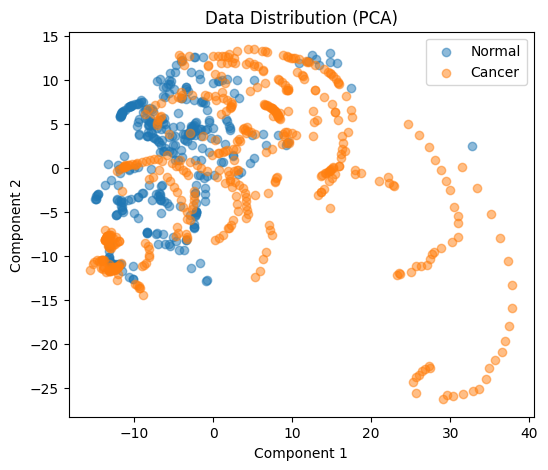

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# Plot cancer (1) and normal (0)
plt.scatter(X_train_pca[y_train==0, 0], X_train_pca[y_train==0, 1], label="Normal", alpha=0.5)
plt.scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1], label="Cancer", alpha=0.5)

plt.title("Data Distribution (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

In [20]:
# Train KNN on PCA data
knn_vis = KNeighborsClassifier(n_neighbors=3)
knn_vis.fit(X_train_pca, y_train)

# Train SVM on PCA data
svm_vis = SVC(kernel='linear')
svm_vis.fit(X_train_pca, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


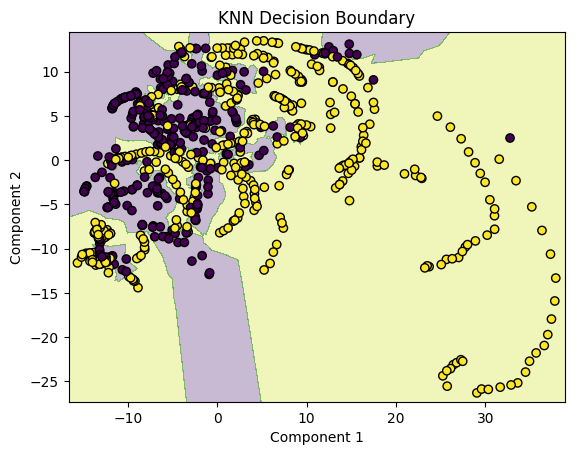

In [17]:
import numpy as np

def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# Plot KNN boundary
plot_decision_boundary(knn_vis, X_train_pca, y_train, "KNN Decision Boundary")

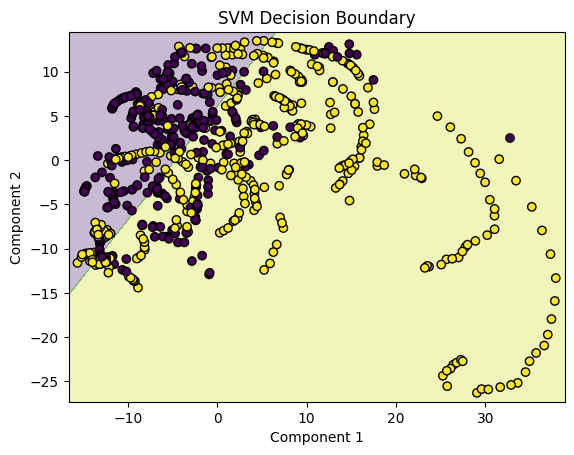

In [18]:
# Plot SVM boundary
plot_decision_boundary(svm_vis, X_train_pca, y_train, "SVM Decision Boundary")

In [4]:
from src.models import build_cnn_model

In [5]:
cnn_model = build_cnn_model()

cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

In [6]:
cnn_model.compile(
    optimizer='adam',                # optimizer
    loss='binary_crossentropy',      # binary classification
    metrics=['accuracy']
)

In [21]:
history = cnn_model.fit(
    X_train, y_train,
    epochs=5,                # keep small (fast training)
    validation_data=(X_test, y_test)
)

Epoch 1/5
25/25 [==============================] - 13s 429ms/step - loss: 0.6280 - accuracy: 0.6248 - val_loss: 0.5458 - val_accuracy: 0.7194
Epoch 2/5
25/25 [==============================] - 13s 521ms/step - loss: 0.4392 - accuracy: 0.7849 - val_loss: 0.3076 - val_accuracy: 0.8776
Epoch 3/5
25/25 [==============================] - 10s 405ms/step - loss: 0.2522 - accuracy: 0.9027 - val_loss: 0.1368 - val_accuracy: 0.9541
Epoch 4/5
25/25 [==============================] - 10s 404ms/step - loss: 0.1469 - accuracy: 0.9501 - val_loss: 0.0611 - val_accuracy: 0.9898
Epoch 5/5
25/25 [==============================] - 11s 451ms/step - loss: 0.0410 - accuracy: 0.9872 - val_loss: 0.0148 - val_accuracy: 1.0000


In [22]:
loss, accuracy = cnn_model.evaluate(X_test, y_test)

print("CNN Accuracy:", accuracy)

7/7 [==============================] - 1s 107ms/step - loss: 0.0148 - accuracy: 1.0000
CNN Accuracy: 1.0


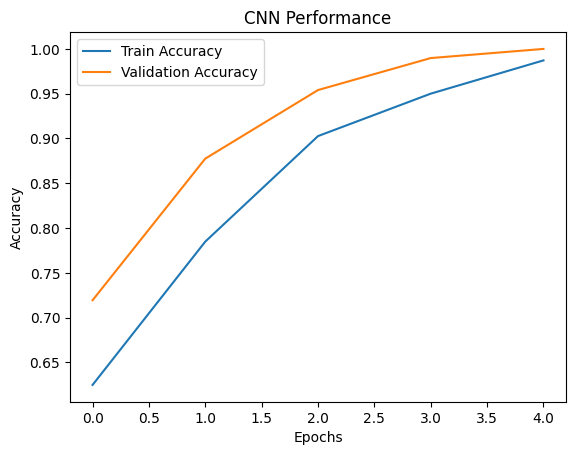

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Performance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [24]:
print("Final Model Comparison")
print("---------------------------")

print(f"KNN Accuracy : {knn_accuracy:.4f}")
print(f"SVM Accuracy : {svm_accuracy:.4f}")
print(f"CNN Accuracy : {accuracy:.4f}")

Final Model Comparison
---------------------------
KNN Accuracy : 0.9898
SVM Accuracy : 1.0000
CNN Accuracy : 1.0000


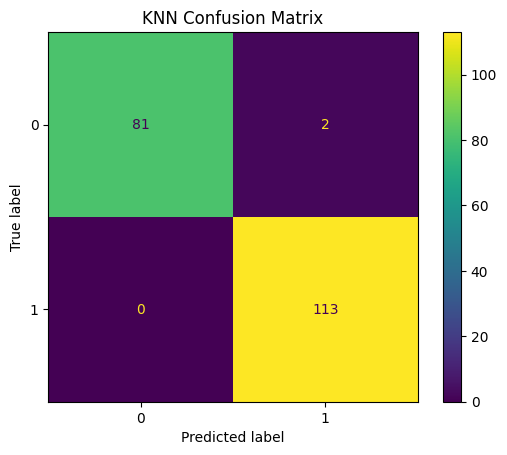

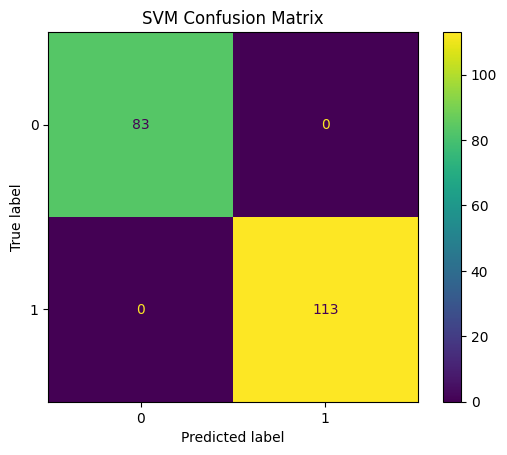

7/7 [==============================] - 1s 169ms/step


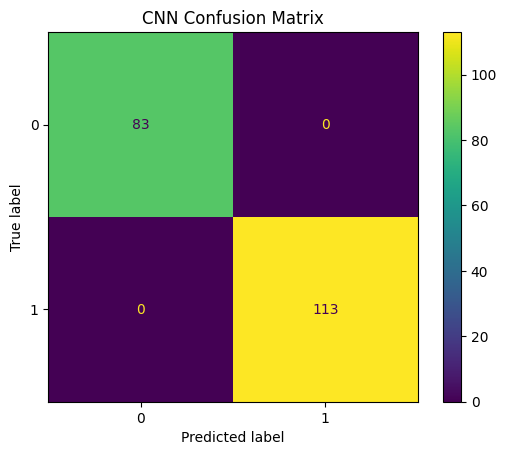

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN Confusion Matrix")
plt.show()

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

# CNN
y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype("int32")
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn).plot()
plt.title("CNN Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print("KNN Report:\n", classification_report(y_test, y_pred_knn))
print("SVM Report:\n", classification_report(y_test, y_pred_svm))
print("CNN Report:\n", classification_report(y_test, y_pred_cnn))

KNN Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        83
           1       0.98      1.00      0.99       113

    accuracy                           0.99       196
   macro avg       0.99      0.99      0.99       196
weighted avg       0.99      0.99      0.99       196

SVM Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       113

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00      1.00       196

CNN Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       113

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00  

In [29]:
# Convert CNN probabilities → 0/1
y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype("int32")

7/7 [==============================] - 1s 120ms/step


In [33]:
print("Model Accuracy Comparison")
print("----------------------------")
print(f"KNN Accuracy : {knn_accuracy:.4f}")
print(f"SVM Accuracy : {svm_accuracy:.4f}")
print(f"CNN Accuracy : {accuracy:.4f}")

Model Accuracy Comparison
----------------------------
KNN Accuracy : 0.9898
SVM Accuracy : 1.0000
CNN Accuracy : 1.0000


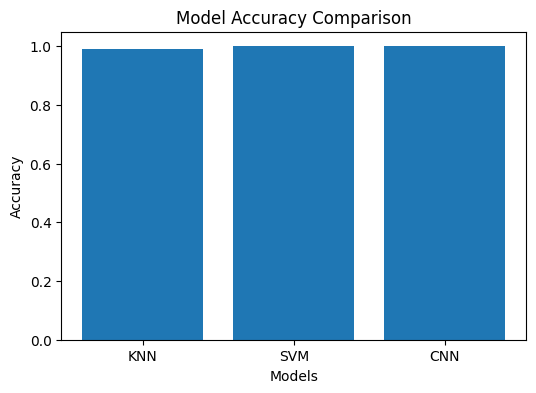

In [35]:
models = ['KNN', 'SVM', 'CNN']
accuracies = [knn_accuracy, svm_accuracy, accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [36]:
cnn_model.save("models/cnn_model.h5")